# Algorithme « Metropolis à marches aléatoires » ("random-walk Metropolis").

## Importation des bibliothèques

In [1]:
# -q : quiet --> réduction des messages
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import time
import functions.generation as generation
from scipy.stats import invgamma, dirichlet
from scipy.stats import gaussian_kde
import math

np.random.seed(20798)

In [3]:
# génération de données

x_star, mu_list, sigma2_list = generation.generate_data(
    generation.n, generation.T, 
    generation.alpha, generation.zeta)

## Calcul de la vraisemblance

$$x_n = y_n + \mu_1 y_{n-1} + \mu_2 y_{n-2}, \qquad y_k \overset{iid}{\sim} \mathcal{N}(0, \sigma^2)$$

On récupère les bruits $y_k$ par récurrence (avec $y_0 = y_{-1} = 0$) :

$$y_k = x_k - \mu_1 y_{k-1} - \mu_2 y_{k-2}, \qquad k = 1, \ldots, n$$

Conditionnellement à $x_1, \ldots, x_{k-1}$, les valeurs $y_{k-1}$ et $y_{k-2}$ sont \textbf{connues}, donc :

$$x_k \mid x_1, \ldots, x_{k-1} \sim \mathcal{N}(\mu_1 y_{k-1} + \mu_2 y_{k-2},\ \sigma^2)$$

ce qui donne la densité conditionnelle 
$$L(x_k \mid x_1, \ldots, x_{k-1}) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\!\left(-\frac{y_k^2}{2\sigma^2}\right)$$

Par la règle de la chaîne :

$$L(x_1, \ldots, x_n) = L(x_1) \prod_{k=2}^{n} L(x_k \mid x_1, \ldots, x_{k-1})$$

$$= \prod_{k=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\!\left(-\frac{y_k^2}{2\sigma^2}\right)$$

$$\boxed{L(x_1, \ldots, x_n \mid \mu_1, \mu_2, \sigma^2) \approx \left(\frac{1}{2\pi\sigma^2}\right)^{n/2} \exp\!\left(-\frac{1}{2\sigma^2}\sum_{k=1}^{n} y_k^2\right)}$$

$$\ell(\mu_1, \mu_2, \sigma^2) = -\frac{n}{2}\log(2\pi) - \frac{n}{2}\log(\sigma^2) - \frac{1}{2\sigma^2}\sum_{k=1}^{n} y_k^2$$

### Posterior et RWMH

Prior sur $\sigma^2$ :

$$\log p(\sigma^2) \propto -(\varsigma_2 + 1)\log(\sigma^2) - \frac{\varsigma_1}{\sigma^2}$$

Prior sur $\beta$ :

$$\log p(\beta) \propto \sum_i (\alpha_i - 1)\log \beta_i$$

Total :
$$\log p(\sigma^2) + \log p(\beta) \propto -(\varsigma_2 + 1)\log(\sigma^2) - \frac{\varsigma_1}{\sigma^2} + \sum_i (\alpha_i - 1)\log \beta_i$$

In [4]:
def log_target(x, mu, sigma2, alpha, zeta):
    """
    log densité cible = log vraisemblance + log prior
    """
    T = len(x)
    
    eps = np.zeros(T)

    # reconstruction des bruits
    for t in range(T):
        eps[t] = x[t]
        if t-1 >= 0:
            eps[t] -= mu[0] * eps[t - 1]
        if t-2 >= 0:
            eps[t] -= mu[1] * eps[t - 2]

    quad = np.sum(eps**2)

    log_lik = -np.log(2*math.pi)*T/2 - np.log(sigma2)*T/2 - quad/(2*sigma2)

    # prior
    s  = (mu[1] + 1) / 2
    b1 = (mu[0] + s) / 2
    b2 = s - b1
    b3 = 1 - b1 - b2
    beta = np.array([b1, b2, b3])

    if np.any(beta <= 0) or np.any(beta >= 1) or sigma2 <= 0:
        return -np.inf

    # log vraissemblance des prior
    log_prior = dirichlet.logpdf(beta, alpha) + invgamma.logpdf(sigma2, zeta[0], scale=zeta[1])

    # log vraissemblance totale
    return log_lik + log_prior

# 'Component-wise' Metropolis-Hastings 
def metropolis_kernel(x, theta, step_mu, step_sigma2, alpha, zeta):
    # on mets à jour sur chaque dimension ET PAS de manière jointe
    # sinon on risque d'avoir certaines dimensions très très mauvaises
    # on avance avec un kernel gaussian
    """
    theta = (mu1, mu2, sigma2)
    """
    mu_cur = theta[:2].copy()
    sigma2_cur = theta[2]
    acc = 0

    # mise à jour de mu1
    mu_prop = mu_cur.copy()
    mu_prop[0] += step_mu * np.random.randn()
    log_alpha = (log_target(x, mu_prop, sigma2_cur, alpha, zeta)
                  - log_target(x, mu_cur,  sigma2_cur, alpha, zeta))
    if np.log(np.random.rand()) < log_alpha:
        mu_cur = mu_prop
        acc += 1

    # mise à jour de mu2
    mu_prop = mu_cur.copy()
    mu_prop[1] += step_mu * np.random.randn()
    log_alpha = (log_target(x, mu_prop, sigma2_cur, alpha, zeta)
                  - log_target(x, mu_cur,  sigma2_cur, alpha, zeta))
    
    if np.log(np.random.rand()) < log_alpha:
        mu_cur = mu_prop
        acc += 1

    # mise à jour de sigma2
    sigma2_prop = sigma2_cur + step_sigma2 * np.random.randn()

    if sigma2_prop <= 0:
        pass  # on rejette directement
    else:
        log_alpha = (log_target(x, mu_cur, sigma2_prop, alpha, zeta)
                - log_target(x, mu_cur, sigma2_cur,  alpha, zeta))
        
        if np.log(np.random.rand()) < log_alpha:
            sigma2_cur = sigma2_prop
            acc+=1

    theta_new = np.array([mu_cur[0], mu_cur[1], sigma2_cur])
    return {'val': theta_new, 'acc': acc / 3}

In [5]:
def rwmh_one_series(x, alpha, zeta, n_iter=10_000,
                    step_mu=0.1, step_sigma2=0.2, seed=20798):
    
    np.random.seed(seed + 2000)

    # début aléatoire de la chaine
    beta = np.random.dirichlet(generation.alpha)  
    mu1_inits   = beta[0] - beta[1]
    mu2_inits   = 2 * (beta[0] + beta[1]) - 1

    mu_init = [mu1_inits, mu2_inits]
    sigma2_init = invgamma.rvs(a=generation.zeta[0], scale=generation.zeta[1])

    N  = n_iter
    s = 0
    chain = np.empty((N, 3))
    chain[0] = [mu_init[0], mu_init[1], sigma2_init]

    # effectuer N interations de metropolis hastings
    for n in range(1, N):
        output = metropolis_kernel(x, chain[n-1], step_mu, step_sigma2, alpha, zeta)
        chain[n] = output['val']
        s += output['acc']

    acc_rate = s / N
    return chain, acc_rate

In [6]:
def plot_chain(all_chains, true_mu, true_sigma2):
    """
    all_chains : liste de R arrays (n_post, 3)
    Superpose les KDE de chaque replicate + vraie valeur.
    """
    true_vals   = [true_mu[0], true_mu[1], true_sigma2]
    param_names = [r"$\mu_1$", r"$\mu_2$", r"$\sigma^2$"]
    R      = len(all_chains)
    colors = plt.cm.tab10.colors

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    for k in range(3):
        ax = axes[k]
        for r in range(R):
            post_r = all_chains[r][:, k]
            kde    = gaussian_kde(post_r)
            x_grid = np.linspace(post_r.min(), post_r.max(), 300)
            ax.plot(
                x_grid, kde(x_grid),
                color=colors[r % 10], alpha=0.7, lw=1.5,
                label=f"R{r+1}" if k == 0 else None
            )
            ax.axvline(post_r.mean(), color=colors[r % 10], lw=1, linestyle='--', alpha=0.5)

        ax.axvline(true_vals[k], color='#D85A30', lw=2, label='vraie valeur' if k == 0 else None)
        ax.set_title(param_names[k])

    axes[0].legend(fontsize=7, ncol=2)
    plt.tight_layout()
    plt.show()


def plot_boxplots_by_replicate(all_chains, true_mu, true_sigma2, index):  # ← index ajouté
    R           = len(all_chains)
    true_vals   = [true_mu[0], true_mu[1], true_sigma2]
    param_names = [r"$\mu_1$", r"$\mu_2$", r"$\sigma^2$"]

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    fig.suptitle(f"Série {index} — distribution post burn-in par replicate", fontsize=13)  # ← utilisé ici

    for j, ax in enumerate(axes):
        data_per_rep = [all_chains[r][:, j] for r in range(R)]

        ax.boxplot(
            data_per_rep,
            tick_labels=[f"R{r+1}" for r in range(R)],
            patch_artist=True,
            boxprops=dict(facecolor="steelblue", alpha=0.6),
            medianprops=dict(color="white", linewidth=2),
            whiskerprops=dict(color="steelblue"),
            capprops=dict(color="steelblue"),
            flierprops=dict(marker='o', markerfacecolor='steelblue', markersize=3, alpha=0.4),
        )
        ax.axhline(true_vals[j], color='#D85A30', linestyle='--', linewidth=1.5, label='vraie valeur')
        ax.set_title(param_names[j])
        ax.set_xlabel("Replicate")
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

[série 0] CPU moyen : 13.0339s ± 0.3662s
[série 0] $\mu_1$ — Biais: 0.045030 | MSE: 0.002043
[série 0] $\mu_2$ — Biais: 0.031214 | MSE: 0.000981
[série 0] $\sigma^2$ — Biais: -0.226625 | MSE: 0.051375
Taux d'acceptation moyen : 29.3%
Erreur de Monte carlo : 18.347276


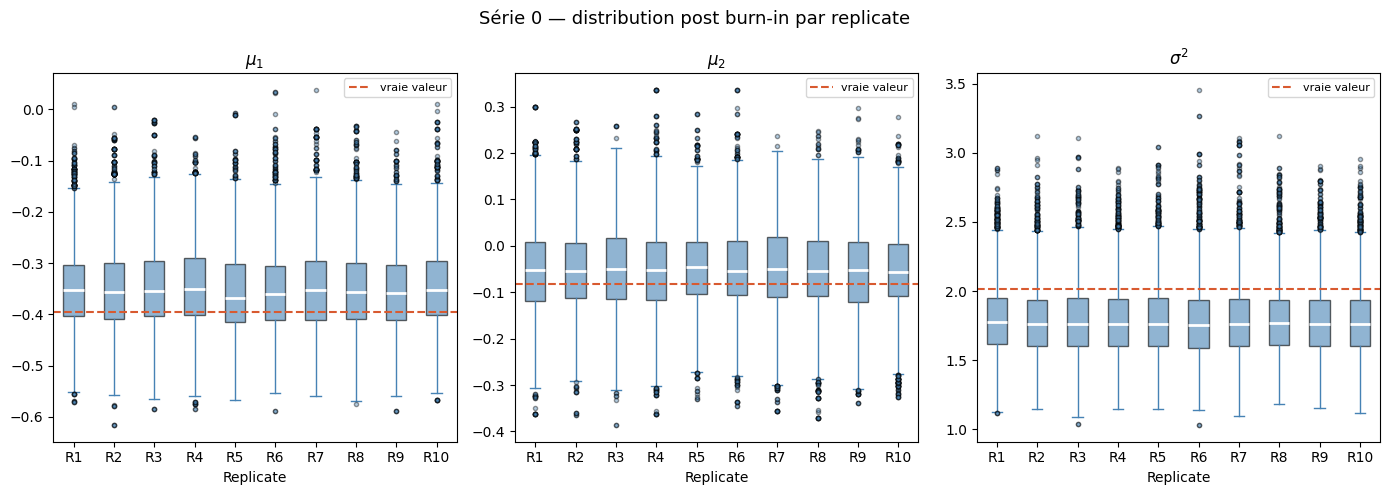

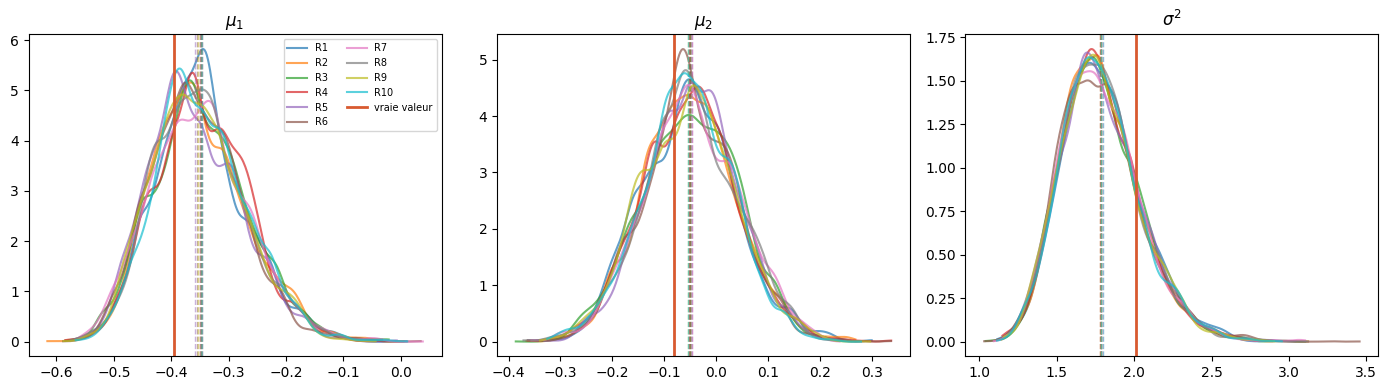

[série 1] CPU moyen : 12.7777s ± 0.8615s
[série 1] $\mu_1$ — Biais: -0.061469 | MSE: 0.003794
[série 1] $\mu_2$ — Biais: 0.032751 | MSE: 0.001105
[série 1] $\sigma^2$ — Biais: -0.080828 | MSE: 0.006536
Taux d'acceptation moyen : 14.3%
Erreur de Monte carlo : 13.234785


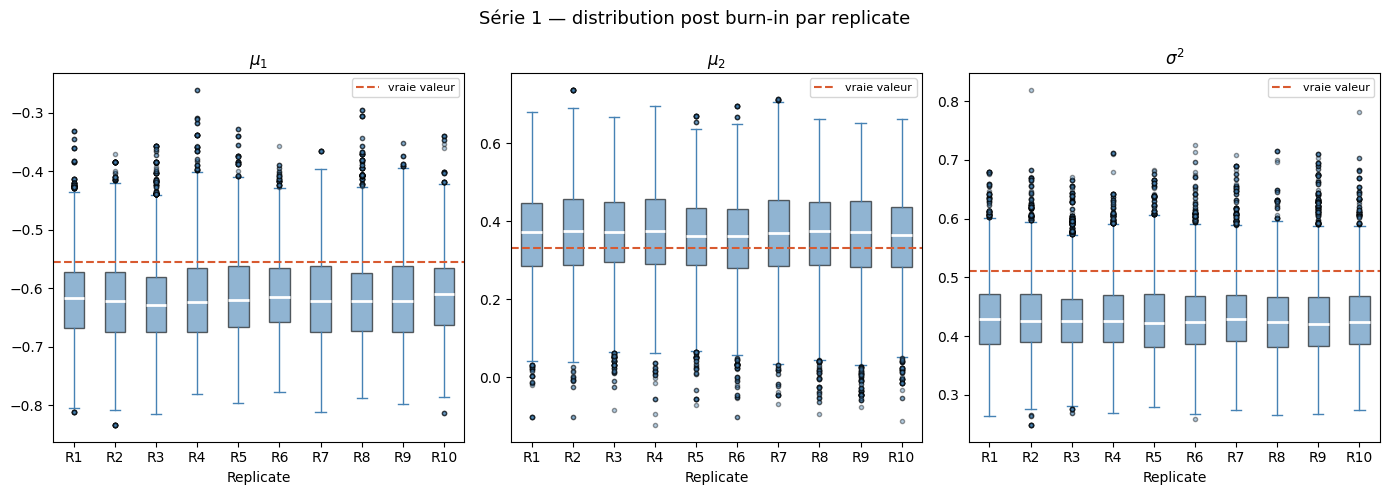

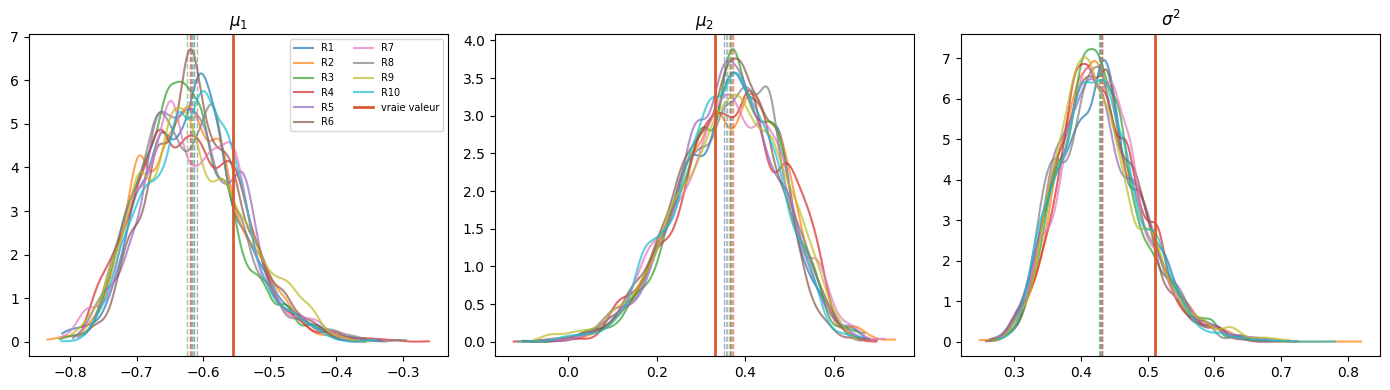

[série 2] CPU moyen : 13.0017s ± 0.5925s
[série 2] $\mu_1$ — Biais: 0.035996 | MSE: 0.001299
[série 2] $\mu_2$ — Biais: -0.137064 | MSE: 0.018795
[série 2] $\sigma^2$ — Biais: 0.623875 | MSE: 0.389766
Taux d'acceptation moyen : 42.2%
Erreur de Monte carlo : 29.645971


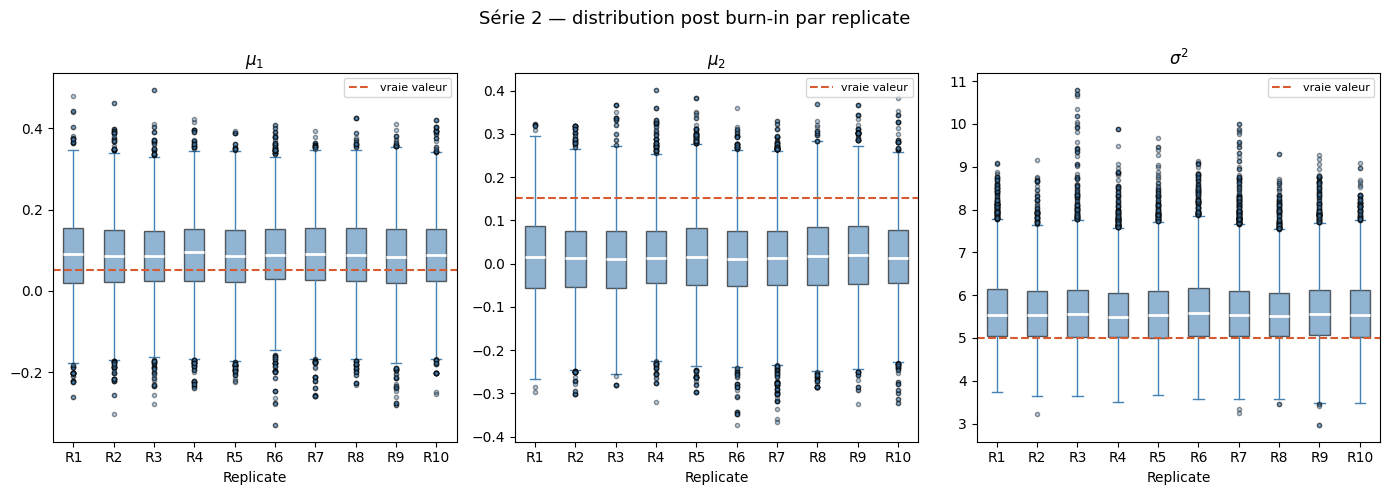

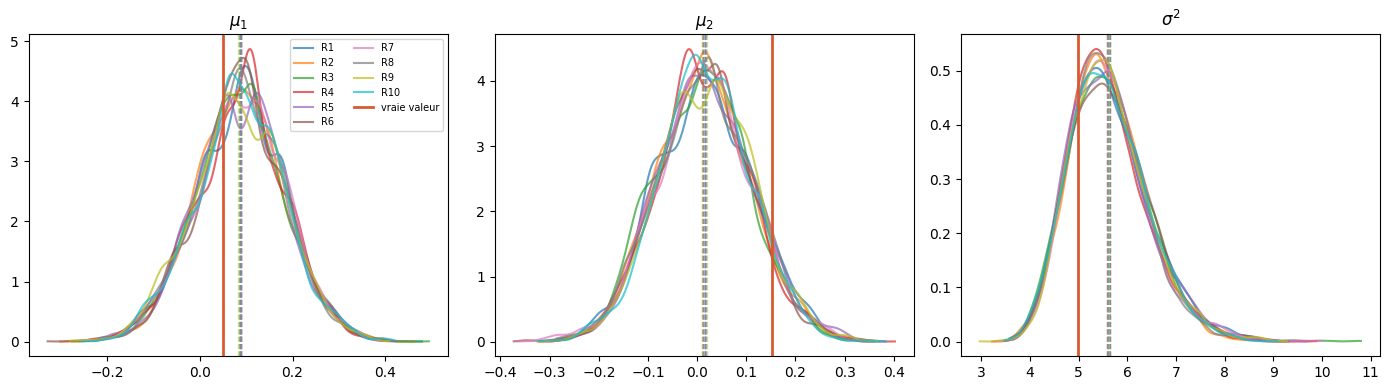

[série 3] CPU moyen : 12.6599s ± 0.3614s
[série 3] $\mu_1$ — Biais: -0.099666 | MSE: 0.009942
[série 3] $\mu_2$ — Biais: -0.180470 | MSE: 0.032581
[série 3] $\sigma^2$ — Biais: -0.129208 | MSE: 0.016704
Taux d'acceptation moyen : 26.9%
Erreur de Monte carlo : 15.046368


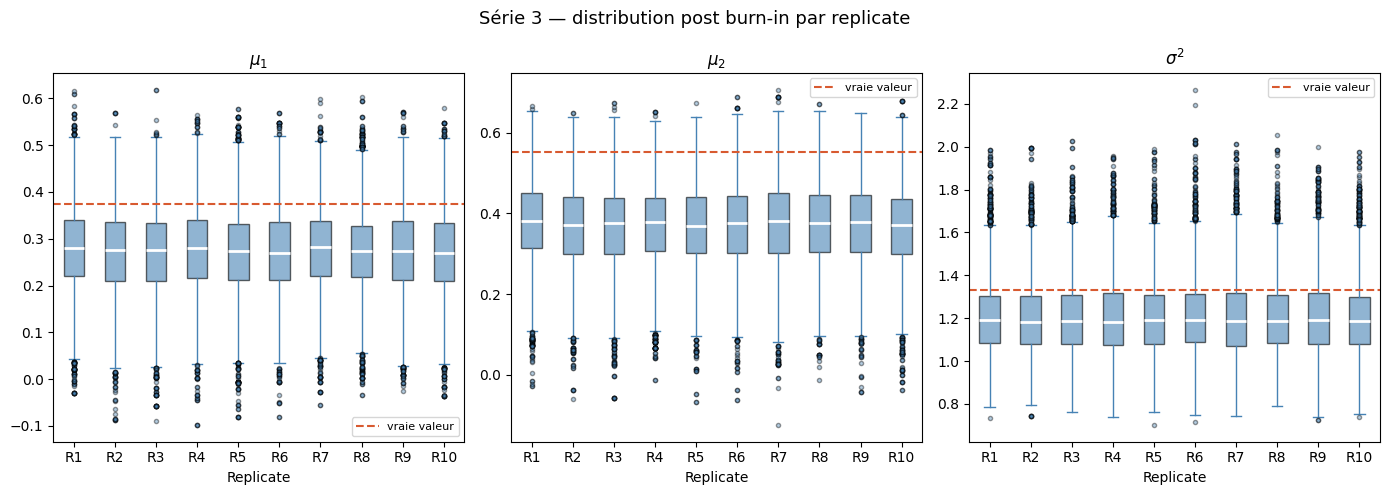

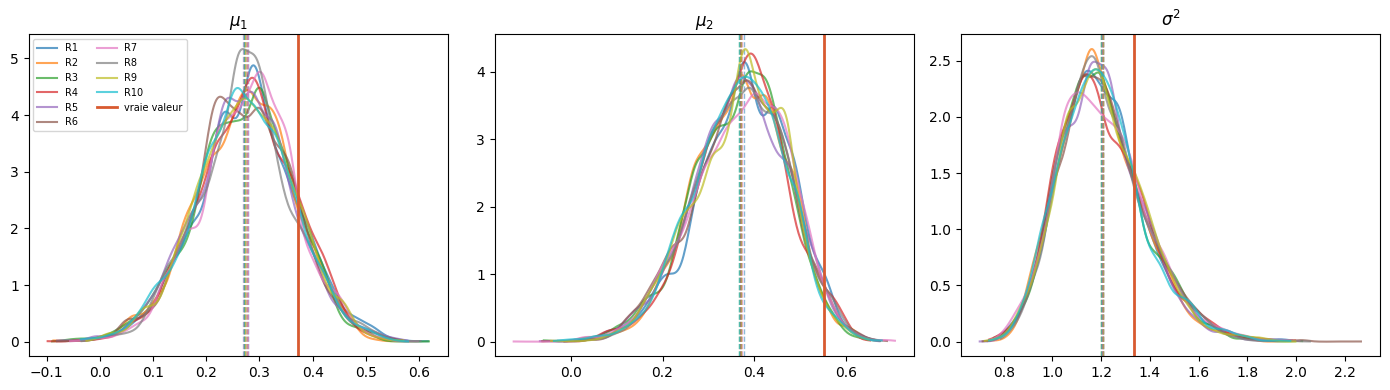

[série 4] CPU moyen : 12.5195s ± 0.2910s
[série 4] $\mu_1$ — Biais: 0.005036 | MSE: 0.000040
[série 4] $\mu_2$ — Biais: 0.029689 | MSE: 0.000891
[série 4] $\sigma^2$ — Biais: -0.009522 | MSE: 0.000110
Taux d'acceptation moyen : 23.8%
Erreur de Monte carlo : 11.568075


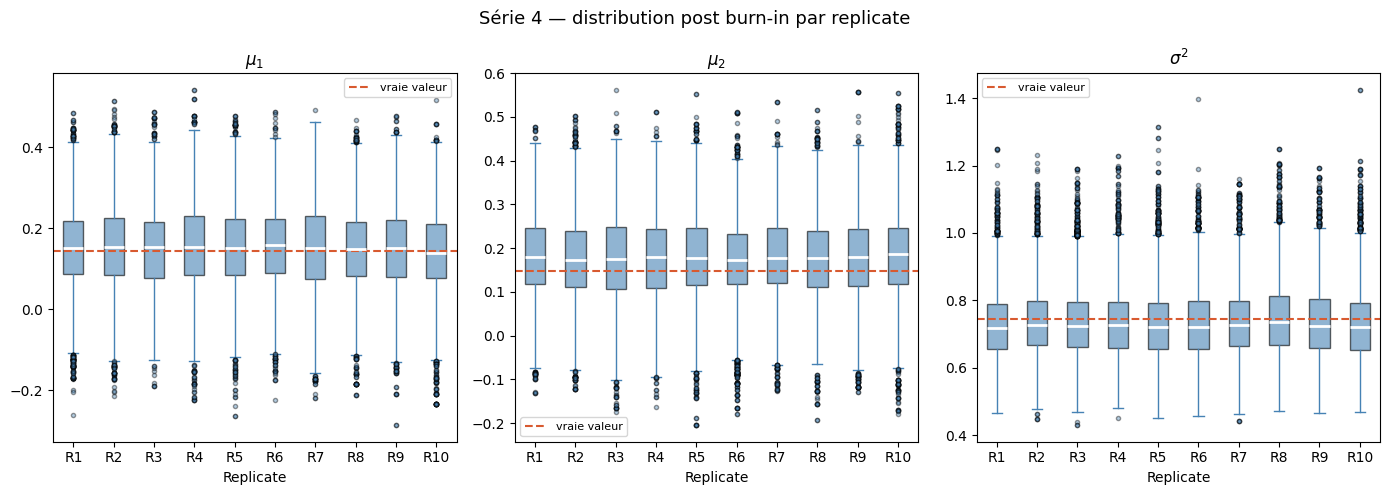

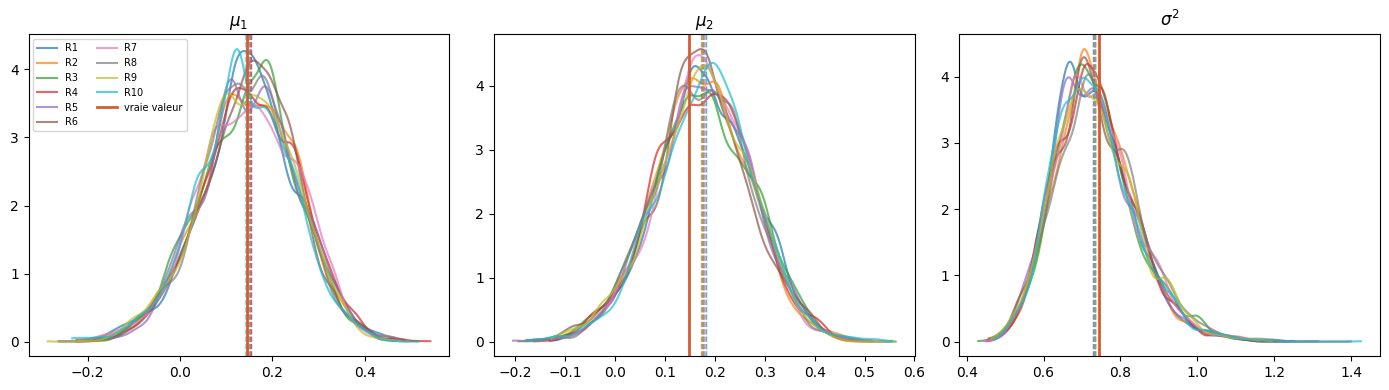

In [7]:
# création d'une pipeline pour effectuer les fonctions sur les 5 séries
# etape 1 : lancer R replicates de RWMH
# etape 2 : calculer un temps moyen d'execution
# etape 3 : calculer les erreurs d'inference, de monte carlo
# etape 4 : plotter un boxplot et une densite

def pipeline(index, x_star, mu_list, sigma2_list, burn_in, n_iterations, R):
    """Lance toute la pipeline pour un dataset donné."""

    cpu_times = []
    all_estimates = []
    acc_rates = []
    all_chains = []
    
    for r in range(R):
        # start du temps de calcul
        t_start = time.process_time()

        chain, acc = rwmh_one_series(
            x_star[index], generation.alpha, generation.zeta, 
            n_iter = n_iterations, step_mu=0.5, step_sigma2=0.5, seed=r
        )

        # fin du temps de calcul
        t_end = time.process_time()
        cpu_time = t_end - t_start
        cpu_times.append(cpu_time)

        post = chain[burn_in:]
        all_estimates.append(post.mean(axis=0))
        acc_rates.append(acc)
        all_chains.append(post)
    
    all_estimates = np.array(all_estimates)
    cpu_moyen = np.mean(cpu_times)
    cpu_std = np.std(cpu_times)  # pour voir si c'est stable
    print(f"[série {index}] CPU moyen : {cpu_moyen:.4f}s ± {cpu_std:.4f}s")

    # --- erreurs ---
    mu, sigma2 = mu_list[index], sigma2_list[index]
    true_vals  = np.array([mu[0], mu[1], sigma2])
    bias = all_estimates.mean(axis=0) - true_vals

    # resimule une série pour calculer la distance
    mu_simulation = [all_estimates.mean(axis=0)[0], all_estimates.mean(axis=0)[1]]
    
    sig = np.sqrt(all_estimates.mean(axis = 0)[2])
    y = np.random.normal(0, sig, 102)
    x_star_new = np.array([y[t+2] + 
                mu_simulation[0]*y[t+1] + 
                mu_simulation[1]*y[t] for t in range(100)])
    
    mce = np.linalg.norm(x_star[index] - x_star_new)

    mse  = ((all_estimates - true_vals) ** 2).mean(axis=0)

    param_names = [r"$\mu_1$", r"$\mu_2$", r"$\sigma^2$"]
    for i, name in enumerate(param_names):
        print(f"[série {index}] {name} — Biais: {bias[i]:.6f} | MSE: {mse[i]:.6f}")
    
    print(f"Taux d'acceptation moyen : {np.mean(acc_rates):.1%}")
    print(f"Erreur de Monte carlo : {mce:.6f}")
    
    # --- boxplots par replicate ---
    plot_boxplots_by_replicate(all_chains, mu, sigma2, index)
    # histogramme
    plot_chain(all_chains, mu, sigma2) 
    
    
for index in range(len(x_star)):
    # remarque : le burn =+/- 10% du nombre d'iterations
    # on ajoute des replicates !!
    pipeline(index, x_star, mu_list, sigma2_list, burn_in=1000, n_iterations = 10_000, R = 10)